# paper_results009 — controlled replication of the successful 005 analysis

This notebook starts from the exact `paper_results005.ipynb` source used in the successful run at commit:

`53b358b458ca4ad5fe3c5ffab85cfbd6443ab733`

The old 005 snapshot defines the canonical cohort. Current values may replace old values only for the same document/index identity. Current-only rows are excluded; old rows or fields missing from current tables are restored from the successful-run snapshot.

Set `USE_CURRENT_REPLICATE_VALUES=False` below for a fully frozen-data replication of the old successful run.


In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import warnings
import glob
warnings.filterwarnings('ignore')
from jupyterthemes import jtplot
jtplot.style()
from sklearn import metrics

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import random

def pyRandColor():
    randNums = [random.random() for _ in range(0, 3)]

    RGB255 = list([ int(i * 255) for i in randNums ])
    RGB1 = list([ round(i, 2) for i in randNums ])
    return RGB1

## Inclusion rule — before any data loading

The paper cohort uses texts of at least **150,000 characters**.

For a current table that contains `text_length`, a current row below this threshold cannot replace its old reference row. The reference tables themselves were the tables used in the successful 005 run.


In [2]:
REFERENCE_COMMIT = "53b358b458ca4ad5fe3c5ffab85cfbd6443ab733"
MIN_TEXT_LENGTH = 150_000

# True = same OLD cohort, refreshed CURRENT values where the same row exists.
# False = exact old values from the successful 005 snapshot.
USE_CURRENT_REPLICATE_VALUES = True

print("Reference commit:", REFERENCE_COMMIT)
print("Minimum text length:", MIN_TEXT_LENGTH)
print("Use current values for matched replicate rows:", USE_CURRENT_REPLICATE_VALUES)


Reference commit: 53b358b458ca4ad5fe3c5ffab85cfbd6443ab733
Minimum text length: 150000
Use current values for matched replicate rows: True



## Data

In [3]:
def getDataFrame(df, varname='human', cols=['perplexity', 'percentage', 'entropy_rate', 'rates']):
    """Preserve the successful 005 loading behavior."""
    import ast
    df = df[cols].copy()
    df = df.dropna(subset=["rates"])
    df["rates"] = df["rates"].apply(ast.literal_eval)

    rates_df = df["rates"].apply(pd.Series)
    rates_df.columns = [f"rates_{i}" for i in rates_df.columns]

    return pd.concat([df.drop(columns=["rates"]), rates_df], axis=1).assign(label=varname)


from pathlib import Path
from io import StringIO
import subprocess
import re

REWRITE_RE = re.compile(r"_(?:0\.9|1\.05|1\.1|1\.5)(?:\.txt)?$", re.IGNORECASE)


def _normalize_index(df):
    out = df.copy()
    out.index = out.index.map(str)
    return out


def read_reference_csv(repo_root, relative_path):
    proc = subprocess.run(
        ["git", "show", f"{REFERENCE_COMMIT}:{relative_path}"],
        cwd=repo_root,
        check=True,
        capture_output=True,
        text=True,
    )
    return _normalize_index(pd.read_csv(StringIO(proc.stdout), index_col=0))


def read_current_csv(repo_root, relative_path):
    return _normalize_index(pd.read_csv(Path(repo_root) / relative_path, index_col=0))


def reconcile_reference_cohort(repo_root, relative_path, dataset_name):
    """
    REWRITE / REPLICATION LOGIC.

    The OLD snapshot defines which documents belong to the replicate cohort.
    CURRENT values may update only the same document identity.

    - current-only rows are excluded;
    - old rows missing from current are restored;
    - missing current fields fall back to the old value;
    - a current row below MIN_TEXT_LENGTH cannot replace the old row;
    - rewrite/perturbation rows are explicitly tagged.
    """
    ref = read_reference_csv(repo_root, relative_path)
    cur = read_current_csv(repo_root, relative_path)

    if "text_length" in ref.columns:
        Lref = pd.to_numeric(ref["text_length"], errors="coerce")
        ref = ref.loc[Lref.isna() | (Lref >= MIN_TEXT_LENGTH)].copy()

    ref_ids = set(ref.index)
    cur_ids = set(cur.index)

    matched_ids = sorted(ref_ids & cur_ids)
    restored_row_ids = sorted(ref_ids - cur_ids)
    current_only_ids = sorted(cur_ids - ref_ids)

    out = ref.copy()
    n_length_rejected = 0
    n_rows_updated = 0
    restored_fields = {}

    if USE_CURRENT_REPLICATE_VALUES:
        for idx in matched_ids:
            crow = cur.loc[idx]

            if "text_length" in cur.columns:
                L = pd.to_numeric(pd.Series([crow.get("text_length")]), errors="coerce").iloc[0]
                if pd.notna(L) and L < MIN_TEXT_LENGTH:
                    n_length_rejected += 1
                    continue

            for col in cur.columns:
                if col not in out.columns:
                    out[col] = np.nan

            for col in cur.columns:
                value = crow.get(col)
                if pd.notna(value):
                    out.at[idx, col] = value
                elif col in ref.columns and pd.notna(ref.at[idx, col]):
                    restored_fields[col] = restored_fields.get(col, 0) + 1

            n_rows_updated += 1

    rewrite_ids = [idx for idx in out.index if REWRITE_RE.search(str(idx))]

    audit = {
        "dataset": dataset_name,
        "path": relative_path,
        "reference_rows": len(ref),
        "current_rows": len(cur),
        "matched_rows": len(matched_ids),
        "current_only_excluded": len(current_only_ids),
        "old_rows_restored": len(restored_row_ids),
        "current_rows_updated": n_rows_updated,
        "current_below_length_fallback": n_length_rejected,
        "rewrite_rows_in_reference_cohort": len(rewrite_ids),
        "restored_fields": restored_fields,
        "restored_row_ids": restored_row_ids,
        "current_only_ids": current_only_ids,
        "rewrite_ids": rewrite_ids,
    }
    return out, audit


## Recognition without training using averged estimate of entropy rate

In [4]:
from pathlib import Path

_CWD = Path.cwd().resolve()
if (_CWD / "api_data_collection").exists():
    REPO_PATH = _CWD
elif (_CWD.parent / "api_data_collection").exists():
    REPO_PATH = _CWD.parent
else:
    raise RuntimeError("Run this notebook from the nero repository root or notebooks/ directory.")

DATA_PATHS = {
    "human1": ("paper_data/legacy/gutenberg/gutenberg_table.csv", 0, "Gutenberg project (legacy 002)"),
    "human2": ("paper_data/legacy/arxiv_entropy/arxiv_table.csv", 0, "Arxiv papers (legacy 002)"),
    "human3": ("api_data_collection/ai_data/loc-pd/loc-pd_detection.csv", 0, "Library of Congress public domain (003)"),
    "human4": ("api_data_collection/ai_data/us-pd/us-pd_detection.csv", 0, "US public domain (003)"),
    "ai0": ("api_data_collection/ai_data/openai/gpt4o/gpt_4o_detection.csv", 1, "API GPT-4o (003)"),
    "ai1": ("paper_data/legacy/ai_longform_gpt4o/ai_web_longform_table.csv", 1, "AI Generated GPT-4o longform (legacy 002)"),
    "ai2": ("paper_data/legacy/ai_longform_gpt3.5/gpt_35_table.csv", 1, "AI Generated GPT-3.5 longform (legacy 002)"),
    "ai3": ("paper_data/legacy/ai_longform_gpt4.0/gpt_40_table.csv", 1, "AI Generated GPT-4.0 longform (legacy 002)"),
    "ai4": ("api_data_collection/ai_data/claude_sonnet_4/claude_detection.csv", 1, "Claude Sonnet 4 (003)"),
    "ai5": ("api_data_collection/ai_data/gemini_2.5_pro/gemini_25_detection.csv", 1, "Gemini 2.5 Pro (003)"),
    "ai6": ("api_data_collection/ai_data/openai/gpt5/gpt_5_detection.csv", 1, "GPT-5 (003)"),
    "ai7": ("api_data_collection/ai_data/openai/gpt4.0/gpt_4zero_detection.csv", 1, "API GPT-4.0 (003)"),
}

raw_replicates = {}
replication_audit = []
NAMES = {}

for key, (relpath, label, display_name) in DATA_PATHS.items():
    reconciled, audit = reconcile_reference_cohort(REPO_PATH, relpath, display_name)
    raw_replicates[key] = reconciled
    replication_audit.append(audit)
    NAMES[key] = display_name
    globals()[key] = getDataFrame(reconciled, varname=label)

dallhuman = pd.concat([human1,human2,human3,human4])
df = pd.concat([human1,human2,human3,human4,ai0,ai1,ai2,ai3,ai4,ai5,ai6,ai7])

print("repo:", REPO_PATH)
print("rows entering the replicated 005 analysis:")
print({name: len(globals()[name]) for name in NAMES})


repo: /D1/Dropbox/ZED/Research/nero
rows entering the replicated 005 analysis:
{'human1': 406, 'human2': 42, 'human3': 77, 'human4': 93, 'ai0': 184, 'ai1': 98, 'ai2': 100, 'ai3': 41, 'ai4': 963, 'ai5': 1043, 'ai6': 212, 'ai7': 42}


## REWRITE / REPLICATION AUDIT

**This is the explicit rewrite section.**

The table below shows where current data were rewritten relative to the old successful 005 cohort.

- `current_only_excluded`: new rows not present in old 005; excluded.
- `old_rows_restored`: old 005 rows missing from the current table; restored.
- `current_below_length_fallback`: current replacements below 150k characters; old row retained.
- `rewrite_rows_in_reference_cohort`: explicit perturbation/rewrite rows (`_0.9`, `_1.05`, `_1.1`, `_1.5`). These enter only if they were already in the old reference cohort.
- `restored_fields`: current matched rows in which a missing field was filled back from the old snapshot.

This is the cell to inspect when explaining a change in AUC after data-table rewrites.


In [5]:
audit_df = pd.DataFrame([
    {k: v for k, v in a.items()
     if k not in ["restored_row_ids", "current_only_ids", "rewrite_ids", "restored_fields"]}
    for a in replication_audit
])
display(audit_df)

for a in replication_audit:
    changed = (
        a["current_only_excluded"]
        or a["old_rows_restored"]
        or a["current_below_length_fallback"]
        or a["rewrite_rows_in_reference_cohort"]
        or a["restored_fields"]
    )
    if changed:
        print("\n---", a["dataset"], "---")
        if a["old_rows_restored"]:
            print("old rows restored:", a["restored_row_ids"])
        if a["current_only_excluded"]:
            print("current-only rows excluded:", a["current_only_ids"])
        if a["rewrite_rows_in_reference_cohort"]:
            print("rewrite/perturbation rows:", a["rewrite_ids"])
        if a["restored_fields"]:
            print("fields restored from old snapshot:", a["restored_fields"])


,dataset,path,reference_rows,current_rows,matched_rows,current_only_excluded,old_rows_restored,current_rows_updated,current_below_length_fallback,rewrite_rows_in_reference_cohort
0,Gutenberg project (legacy 002),paper_data/legacy/gutenberg/gutenberg_table.csv,406,406,406,0,0,406,0,0
1,Arxiv papers (legacy 002),paper_data/legacy/arxiv_entropy/arxiv_table.csv,42,50,0,50,42,0,0,0
2,Library of Congress public domain (003),api_data_collection/ai_data/loc-pd/loc-pd_dete...,101,101,101,0,0,101,0,0
3,US public domain (003),api_data_collection/ai_data/us-pd/us-pd_detect...,99,99,99,0,0,99,0,0
4,API GPT-4o (003),api_data_collection/ai_data/openai/gpt4o/gpt_4...,184,343,184,159,0,184,0,19
5,AI Generated GPT-4o longform (legacy 002),paper_data/legacy/ai_longform_gpt4o/ai_web_lon...,98,98,98,0,0,98,0,0
6,AI Generated GPT-3.5 longform (legacy 002),paper_data/legacy/ai_longform_gpt3.5/gpt_35_ta...,100,100,100,0,0,100,0,0
7,AI Generated GPT-4.0 longform (legacy 002),paper_data/legacy/ai_longform_gpt4.0/gpt_40_ta...,41,41,41,0,0,41,0,0
8,Claude Sonnet 4 (003),api_data_collection/ai_data/claude_sonnet_4/cl...,963,1015,963,52,0,963,0,14
9,Gemini 2.5 Pro (003),api_data_collection/ai_data/gemini_2.5_pro/gem...,1043,1045,1043,2,0,1043,0,44



--- Arxiv papers (legacy 002) ---
old rows restored: ['1104', '1110', '1206', '1208', '1210', '1211', '1212', '1305', '1307', '1308', '1403', '1501', '1503', '1603', '1705', '1709', '1802', '1805', '1807', '1811', '1902', '1904', '1905', '1912', '2003', '2004', '2006', '2007', '2011', '2101', '2102', '2110', '2201', '2212', '2409', '2411', '2505', '705', '710', '805', '807', '910']
current-only rows excluded: ['PAPERS_0705.0752v1.txt', 'PAPERS_0710.4057v1.txt', 'PAPERS_0805.0585v1.txt', 'PAPERS_0807.4755v1.txt', 'PAPERS_0910.5896v2.txt', 'PAPERS_1104.4805v3.txt', 'PAPERS_1110.4891v2.txt', 'PAPERS_1206.6908v1.txt', 'PAPERS_1208.4204v1.txt', 'PAPERS_1208.4233v3.txt', 'PAPERS_1210.0336v1.txt', 'PAPERS_1211.5875v2.txt', 'PAPERS_1212.6498v2.txt', 'PAPERS_1305.0708v3.txt', 'PAPERS_1307.6794v5.txt', 'PAPERS_1308.5150v2.txt', 'PAPERS_1403.6087v3.txt', 'PAPERS_1501.00221v1.txt', 'PAPERS_1501.03303v2.txt', 'PAPERS_1503.09146v2.txt', 'PAPERS_1603.05065v1.txt', 'PAPERS_1705.07444v2.txt', 'PAPERS_

In [6]:
#dh=df.copy()
df_=df.copy()
df_['nz_entropy_rate']=df[[x for x in df_.columns if 'rates' in x]].replace(0,None).median(axis=1)

def func1(row):
    n=0
    for i in row.values:
        if i == 0:
            n=n+1
    return n
nz=(df!=0).iloc[:,3:43].mean(axis=1)
nzstd=(df!=0).iloc[:,3:43].std(axis=1)
df_['nzmean'] = nz
df_['nzstd'] = nzstd
df_['nzero'] = df.apply(func1,axis=1)
#df=df.drop('nzero',axis=1)

In [7]:
ytrue=df_.label.values


ypred= df_.fillna(0).nz_entropy_rate.values #+ df.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr, tpr, thresholds = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e=auc(fpr, tpr)
print('nzent',auc_e)
D1=pd.DataFrame({'fpr':fpr,'tpr':tpr,'threshold':thresholds}).set_index('threshold').sort_index().dropna()
#D1.to_csv('./src/neroroce.csv')

ypred=  df_.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr2, tpr2, thresholds2 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e2=auc(fpr2, tpr2)
print(auc_e2)
D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2]).to_csv('neroroce.csv')


ypred=  df_.fillna(0).nzero.values
#y_pred=np.median(X,axis=1)
fpr3, tpr3, thresholds3 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e3=auc(fpr3, tpr3)
print(auc_e3)
D3=pd.DataFrame({'fpr':fpr3,'tpr':tpr3,'threshold':thresholds3}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2,D3]).to_csv('neroroce.csv')



ypred=  df_.fillna(0).perplexity.values
#y_pred=np.median(X,axis=1)
fprP, tprP, thresholdsP = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_P=auc(fprP, tprP)
print('px',auc_P)
DP=pd.DataFrame({'fpr':fprP,'tpr':tprP,'threshold':thresholdsP}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


ypred=  df_.fillna(0).percentage.values
#y_pred=np.median(X,axis=1)
fprPc, tprPc, thresholdsPc = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_Pc=auc(fprPc, tprPc)
print('%->',auc_Pc)
DPc=pd.DataFrame({'fpr':fprPc,'tpr':tprPc,'threshold':thresholdsPc}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


nzent 0.8300681384770706
0.714894330478248
0.5701374590342888
px 0.7323459948591575
%-> 0.9393882373375695


In [8]:
pd.DataFrame(ytrue).to_csv('ytrue.csv')


In [9]:
from zedstat import zedstat 
zte=zedstat.processRoc(df=pd.read_csv('neroroce.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

zte.smooth(STEP=0.1,
    interpolate=True,
    convexify=True)
zte.allmeasures(interpolate=True)
zte.usample(precision=2)
zte.getBounds()

auc_e=np.array(zte.auc(alpha=.05))*100
deltae=(auc_e[1]-auc_e[2])/2
le=str(auc_e[0])[:4]+'%'
zte.auc(alpha=.05)

(0.8374379513160533,
 np.float64(0.8518355148242369),
 np.float64(0.8230403878078696))

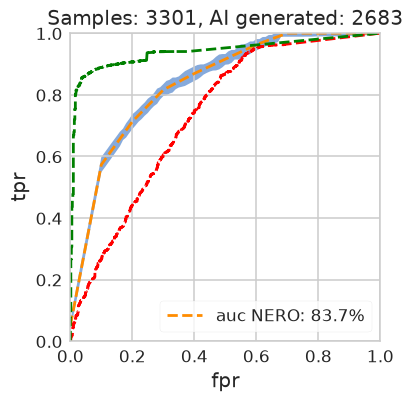

In [10]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
#ax=ztz.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)

#plt.fill_between(x=ztz.get().index, y1=ztz.df_lim['U'].tpr,y2=ztz.df_lim['L'].tpr, alpha=.6)
DP.sort_values('tpr').set_index('fpr').tpr.plot(style='--',ax=ax,color='red',lw=2)
DPc.sort_values('tpr').set_index('fpr').tpr.plot(style='--',ax=ax,color='green',lw=2)

#DP.to_csv('perplexity_all.csv')
#DPc.to_csv('percentage_all.csv')

ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO: '+le],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining1.pdf',bbox_inches='tight',transparent=True)

In [11]:
#dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
#dx.to_csv('nero_all_notraining.csv')

In [12]:
from sklearn import metrics
df_all=pd.concat([human1,human2,human3,human4,ai0,ai1,ai2,ai3,ai4,ai5,ai6,ai7])
SUBSET='ALL'

In [13]:
#dh=df.copy()
df_=df_all.copy()
df_['nz_entropy_rate']=df_[[x for x in df_.columns if 'rates' in x]].replace(0,None).median(axis=1)

def func1(row):
    n=0
    for i in row.values:
        if i == 0:
            n=n+1
    return n
nz=(df_!=0).iloc[:,3:43].mean(axis=1)
nzstd=(df_!=0).iloc[:,3:43].std(axis=1)
df_['nzmean'] = nz
df_['nzstd'] = nzstd
df_['nzero'] = df_.apply(func1,axis=1)

In [14]:
ytrue=df_.label.values
ypred= df_.fillna(0).nz_entropy_rate.values #+ df.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr, tpr, thresholds = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e=auc(fpr, tpr)
print('nzent',auc_e)
D1=pd.DataFrame({'fpr':fpr,'tpr':tpr,'threshold':thresholds}).set_index('threshold').sort_index().dropna()
#D1.to_csv('./src/neroroce.csv')

ypred=  df_.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr2, tpr2, thresholds2 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e2=auc(fpr2, tpr2)
print(auc_e2)
D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2]).to_csv('neroroce_frac.csv')


ypred=  df_.fillna(0).nzero.values
#y_pred=np.median(X,axis=1)
fpr3, tpr3, thresholds3 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e3=auc(fpr3, tpr3)
print(auc_e3)
D3=pd.DataFrame({'fpr':fpr3,'tpr':tpr3,'threshold':thresholds3}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2,D3]).to_csv('neroroce_frac.csv')



ypred=  df_.fillna(0).perplexity.values
#y_pred=np.median(X,axis=1)
fprP, tprP, thresholdsP = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_P=auc(fprP, tprP)
print('px',auc_P)
DP=pd.DataFrame({'fpr':fprP,'tpr':tprP,'threshold':thresholdsP}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')
DP.to_csv('perplexity_frac.csv')


ypred=  df_.fillna(0).percentage.values
#y_pred=np.median(X,axis=1)
fprPc, tprPc, thresholdsPc = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_Pc=auc(fprPc, tprPc)
print('%->',auc_Pc)
DPc=pd.DataFrame({'fpr':fprPc,'tpr':tprPc,'threshold':thresholdsPc}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
DPc = DPc[~np.isinf(DPc.index)]
DPc.to_csv('percentage_frac.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


nzent 0.8300681384770706
0.714894330478248
0.5836795139479427
px 0.7323459948591575
%-> 0.9393882373375695


In [15]:
from zedstat import zedstat 
zte=zedstat.processRoc(df=pd.read_csv('neroroce_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

zte.smooth(STEP=0.001)
zte.allmeasures(interpolate=True)
zte.usample(precision=2)
zte.getBounds()

auc_e=np.array(zte.auc(alpha=.05))*100
deltae=(auc_e[1]-auc_e[2])/2
le=str(auc_e[0])[:4]+'%'
zte.auc(alpha=.05)


ztpc=zedstat.processRoc(df=pd.read_csv('percentage_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

ztpc.smooth(STEP=0.001)
ztpc.allmeasures(interpolate=True)
ztpc.usample(precision=2)
ztpc.getBounds()

auc_pc=np.array(ztpc.auc(alpha=.05))*100
deltapc=(auc_pc[1]-auc_pc[2])/2
lpc=str(auc_pc[0])[:4]+'%'
ztpc.auc(alpha=.05)



ztpx=zedstat.processRoc(df=pd.read_csv('perplexity_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

ztpx.smooth(STEP=0.001)
ztpx.allmeasures(interpolate=True)
ztpx.usample(precision=2)
ztpx.getBounds()

auc_px=np.array(ztpx.auc(alpha=.05))*100
deltapx=(auc_px[1]-auc_px[2])/2
lpx=str(auc_px[0])[:4]+'%'
ztpx.auc(alpha=.05)

(0.7373862067896427,
 np.float64(0.7565747950344432),
 np.float64(0.7181976185448422))

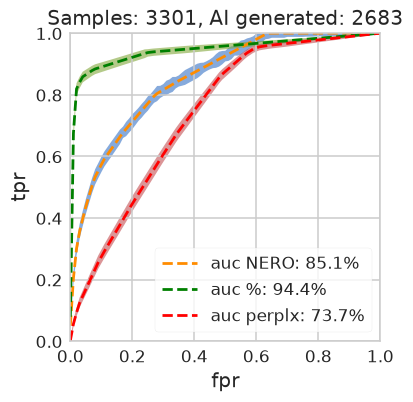

In [16]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
ax=ztpc.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
ax=ztpx.get().tpr.plot(style='--',ax=ax,color='red',lw=2)

plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpc.get().index, y1=ztpc.df_lim['U'].tpr,y2=ztpc.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpx.get().index, y1=ztpx.df_lim['U'].tpr,y2=ztpx.df_lim['L'].tpr, alpha=.6)


dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_notraining.csv')
dx=pd.DataFrame({'tpr_upper':ztpc.df_lim['U'].tpr,'tpr_lower':ztpc.df_lim['L'].tpr}).join(ztpc.get()['tpr'])
dx.to_csv('percentage_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztpx.df_lim['U'].tpr,'tpr_lower':ztpx.df_lim['L'].tpr}).join(ztpx.get()['tpr'])
dx.to_csv('perplexity_'+SUBSET+'.csv')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO: '+le,'auc %: '+lpc,'auc perplx: '+lpx],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining'+SUBSET+'.pdf',bbox_inches='tight',transparent=True)

# AUC distribution for subsets

In [17]:
import itertools
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import auc as sk_auc
from zedstat import zedstat
from tqdm import tqdm

def _roc_df_from_scores(ytrue, yscore, *, pos_label):
    fpr, tpr, thr = metrics.roc_curve(ytrue, yscore, pos_label=pos_label)
    df = pd.DataFrame({"threshold": thr, "fpr": fpr, "tpr": tpr}).dropna()
    # Keep finite only
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df


def _dedupe_by_fpr_keep_max_tpr(df: pd.DataFrame) -> pd.DataFrame:
    # zedstat later indexes by fpr; ensure enough unique fpr points
    df = df.sort_values("fpr")
    df = df.groupby("fpr", as_index=False)["tpr"].max()
    return df.sort_values("fpr")


def _zedstat_auc_from_roc_df(
    roc_df: pd.DataFrame,
    *,
    total_samples: int,
    positive_samples: int,
    prevalence: float,
    alpha_process: float,
    alpha_auc: float,
    smooth_step: float,
    order: int,
):
    """
    Returns (auc_percent, used_order, method_str).
    Falls back to sklearn AUC if zedstat spline bounds are impossible.
    """
    roc_df = roc_df[["fpr", "tpr"]].copy()
    roc_df = _dedupe_by_fpr_keep_max_tpr(roc_df)

    n_unique = roc_df["fpr"].nunique()
    if n_unique < 2:
        # Not even a curve
        return float("nan"), None, "nan"

    # pick a safe spline order for zedstat's spline interpolation
    safe_order = min(order, n_unique - 1)
    if safe_order < 1:
        # linear AUC directly
        return float(sk_auc(roc_df["fpr"].values, roc_df["tpr"].values) * 100.0), 1, "sklearn"

    try:
        zt = zedstat.processRoc(
            df=roc_df,
            order=safe_order,
            total_samples=total_samples,
            positive_samples=positive_samples,
            alpha=alpha_process,
            prevalence=prevalence,
        )
        zt.smooth(STEP=smooth_step)
        zt.allmeasures(interpolate=True)
        zt.usample(precision=2)
        zt.getBounds()
        auc_val = float(np.array(zt.auc(alpha=alpha_auc))[0] * 100.0)
        return auc_val, safe_order, "zedstat"
    except Exception:
        # final fallback: compute AUC directly from the deduped ROC
        return float(sk_auc(roc_df["fpr"].values, roc_df["tpr"].values) * 100.0), safe_order, "sklearn"


def compute_auc_triple_for_df(
    df_gpt5: pd.DataFrame,
    *,
    label_col: str = "label",
    entropy_rate_col: str = "entropy_rate",
    perplexity_col: str = "perplexity",
    percentage_col: str = "percentage",
    rates_col_substring: str = "rates",
    nz_slice: tuple[int, int] = (3, 43),
    prevalence: float = 0.5,
    alpha_process: float = 0.01,
    alpha_auc: float = 0.05,
    smooth_step: float = 0.001,
    order: int = 3,
    require_both_classes: bool = True,
):
    df_ = df_gpt5.copy()

    if label_col not in df_.columns:
        raise ValueError(f"Missing label column: '{label_col}'")

    ytrue = df_[label_col].values

    if require_both_classes and len(np.unique(ytrue)) < 2:
        # cannot define ROC/AUC
        return (np.nan, np.nan, np.nan)

    # nz_entropy_rate
    rate_cols = [c for c in df_.columns if rates_col_substring in c]
    if not rate_cols:
        raise ValueError(f"No columns found containing substring '{rates_col_substring}'")
    df_["nz_entropy_rate"] = df_[rate_cols].replace(0, None).median(axis=1)

    # nzero across row (as in your code)
    def func1(row):
        n = 0
        for i in row.values:
            if i == 0:
                n += 1
        return n

    lo, hi = nz_slice
    df_["nzmean"] = (df_ != 0).iloc[:, lo:hi].mean(axis=1)
    df_["nzstd"] = (df_ != 0).iloc[:, lo:hi].std(axis=1)
    df_["nzero"] = df_.apply(func1, axis=1)

    total_samples = len(ytrue)
    positive_samples = int(np.sum(ytrue))

    # --- “neroroce” composite: D1 + D2 + D3 (all with pos_label=0) ---
    roc1 = _roc_df_from_scores(ytrue, df_.fillna(0)["nz_entropy_rate"].values, pos_label=0)
    roc2 = _roc_df_from_scores(ytrue, df_.fillna(0)[entropy_rate_col].values, pos_label=0)
    roc3 = _roc_df_from_scores(ytrue, df_.fillna(0)["nzero"].values, pos_label=0)

    neroroce = pd.concat([roc1[["fpr", "tpr"]], roc2[["fpr", "tpr"]], roc3[["fpr", "tpr"]]], axis=0)
    auc_e, _, _ = _zedstat_auc_from_roc_df(
        neroroce,
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    # --- percentage (pos_label=1) ---
    roc_pc = _roc_df_from_scores(ytrue, df_.fillna(0)[percentage_col].values, pos_label=1)
    auc_pc, _, _ = _zedstat_auc_from_roc_df(
        roc_pc[["fpr", "tpr"]],
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    # --- perplexity (pos_label=1) ---
    roc_px = _roc_df_from_scores(ytrue, df_.fillna(0)[perplexity_col].values, pos_label=1)
    auc_px, _, _ = _zedstat_auc_from_roc_df(
        roc_px[["fpr", "tpr"]],
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    return auc_e, auc_pc, auc_px


def auc_triples_over_subsets(
    dfs: dict[str, pd.DataFrame],
    *,
    human_keys=("human1", "human2", "human3", "human4"),
    ai_keys=("ai0", "ai1", "ai2", "ai3", "ai4", "ai5", "ai6", "ai7"),
    min_humans=1,
    min_ais=1,
    human_subset_sizes=(1,),
    ai_subset_sizes=(1,),
    drop_nan_triples=True,
    **auc_kwargs,
) -> pd.DataFrame:
    missing = [k for k in (*human_keys, *ai_keys) if k not in dfs]
    if missing:
        raise KeyError(f"Missing dfs entries for: {missing}")

    rows = []
    for hs in human_subset_sizes:
        for humans_sel in itertools.combinations(human_keys, hs):
            for asz in tqdm(ai_subset_sizes):
                for ais_sel in itertools.combinations(ai_keys, asz):
                    if len(humans_sel) < min_humans or len(ais_sel) < min_ais:
                        continue
                    chosen = list(humans_sel) + list(ais_sel)
                    df_cat = pd.concat([dfs[k] for k in chosen], axis=0, ignore_index=True)

                    a1, a2, a3 = compute_auc_triple_for_df(df_cat, **auc_kwargs)

                    if drop_nan_triples and (np.isnan(a1) or np.isnan(a2) or np.isnan(a3)):
                        continue

                    rows.append(
                        {
                            "humans": tuple(humans_sel),
                            "ais": tuple(ais_sel),
                            "n_humans": len(humans_sel),
                            "n_ais": len(ais_sel),
                            "auc_neroroc": a1,
                            "auc_percentage": a2,
                            "auc_perplexity": a3,
                            "auc_mean": np.nanmean([a1, a2, a3]),
                        }
                    )

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values("auc_mean", ascending=False)
    return out

In [18]:
%%time
dfs = {
    "human1": human1, "human2": human2, "human3": human3, "human4": human4,
    "ai0": ai0, "ai1": ai1, "ai2": ai2, "ai3": ai3,
    "ai4": ai4, "ai5": ai5, "ai6": ai6, "ai7": ai7,
}

res = auc_triples_over_subsets(
    dfs,
    human_subset_sizes=tuple(range(1, 5)),
    ai_subset_sizes=tuple(range(1, 9))
)

 38%|████████████████▌                           | 3/8 [00:18<00:31,  6.32s/it]


CPU times: user 1min 1s, sys: 66.4 ms, total: 1min 1s
Wall time: 1min 2s


KeyboardInterrupt: 

In [19]:
import numpy as np
from scipy import stats

alpha=0.01
pct=int(np.round(100*(1-alpha),0))
def mean_ci(x, alpha=alpha):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan

    mu = x.mean()
    s = x.std(ddof=1)
    se = s / np.sqrt(n)

    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    lo = mu - tcrit * se
    hi = mu + tcrit * se
    return mu, lo, hi


m_e, lo_e, hi_e   = mean_ci(res.auc_neroroc)
m_px, lo_px, hi_px = mean_ci(res.auc_perplexity)
m_pc, lo_pc, hi_pc = mean_ci(res.auc_percentage)

print(f"NeuroROC AUC   : {m_e:.3f}  ({pct}% CI [{lo_e:.3f}, {hi_e:.3f}])")
print(f"Perplexity AUC : {m_px:.3f}  ({pct}% CI [{lo_px:.3f}, {hi_px:.3f}])")
print(f"Percentage AUC : {m_pc:.3f}  ({pct}% CI [{lo_pc:.3f}, {hi_pc:.3f}])")


NameError: name 'res' is not defined

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Collect data
labels = ["Nero", "Perplexity", "Percentage"]
data = [
    np.asarray(res.auc_neroroc, dtype=float),
    np.asarray(res.auc_perplexity, dtype=float),
    np.asarray(res.auc_percentage, dtype=float),
]

means, los, his = [], [], []
for x in data:
    m, lo, hi = mean_ci(x)
    means.append(m)
    los.append(lo)
    his.append(hi)

xpos = np.arange(len(labels))

plt.figure(figsize=(7,5))

# Scatter points with jitter
rng = np.random.default_rng(0)
for i, x in enumerate(data):
    x = x[~np.isnan(x)]
    jitter = rng.normal(0, 0.05, size=len(x))
    plt.scatter(
        np.full_like(x, xpos[i]) + jitter,
        x,
        alpha=0.35,
        s=18,
        linewidths=0
    )

# Error bars (mean ± CI)
yerr = np.vstack([
    np.array(means) - np.array(los),
    np.array(his) - np.array(means)
])

plt.errorbar(
    xpos,
    means,
    yerr=yerr,
    fmt='o',
    capsize=6,
    markersize=8,
    linewidth=2,
    zorder=10
)

plt.xticks(xpos, labels)
plt.ylabel("AUC")
plt.title(f"AUC distributions across {len(res)} human×AI subsets\n({pct}% t-intervals)")
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


NameError: name 'res' is not defined

In [21]:
res

NameError: name 'res' is not defined

In [22]:
import numpy as np
import pandas as pd

# ---- 1) scatter points (jittered) dataframe ----
labels = ["Nero", "Perplexity", "Percentage"]
data = [
    np.asarray(res.auc_neroroc, dtype=float),
    np.asarray(res.auc_perplexity, dtype=float),
    np.asarray(res.auc_percentage, dtype=float),
]

rng = np.random.default_rng(0)

rows = []
for i, (lab, x) in enumerate(zip(labels, data)):
    x = x[~np.isnan(x)]
    jitter = rng.normal(0, 0.05, size=len(x))
    for y, j in zip(x, jitter):
        rows.append(
            {
                "metric": lab,
                "x_center": i,          # integer category position
                "x_jitter": float(j),   # jitter added
                "x": float(i + j),      # final x used in scatter
                "auc": float(y),
            }
        )

df_scatter = pd.DataFrame(rows)
df_scatter.to_csv("auc_scatter_pgf.csv", index=False)

# ---- 2) summary (mean + CI) dataframe ----
summ_rows = []
for i, lab in enumerate(labels):
    mu, lo, hi = mean_ci(df_scatter.loc[df_scatter.metric == lab, "auc"].values)
    summ_rows.append(
        {
            "metric": lab,
            "x": i,
            "mean": float(mu),
            "ci_lo": float(lo),
            "ci_hi": float(hi),
            "err_lo": float(mu - lo),   # for pgfplots y error bars if desired
            "err_hi": float(hi - mu),
            "alpha": float(alpha),
            "pct": int(pct),
            "n": int(df_scatter.loc[df_scatter.metric == lab, "auc"].shape[0]),
        }
    )

df_summary = pd.DataFrame(summ_rows)
df_summary.to_csv("auc_summary_pgf.csv", index=False)

print("Wrote:", "auc_scatter_pgf.csv", "auc_summary_pgf.csv")
display(df_summary)
display(df_scatter)


NameError: name 'res' is not defined

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare long-form dataframe
df_plot = pd.DataFrame({
    "AUC": np.concatenate([
        np.asarray(res.auc_neroroc, dtype=float),
        np.asarray(res.auc_perplexity, dtype=float),
        np.asarray(res.auc_percentage, dtype=float),
    ]),
    "Metric": (
        ["Nero"] * len(res.auc_neroroc)
        + ["Perplexity"] * len(res.auc_perplexity)
        + ["Percentage"] * len(res.auc_percentage)
    )
}).dropna()

plt.figure(figsize=(7,5))

sns.violinplot(
    data=df_plot,
    x="Metric",
    y="AUC",
    inner=None,          # no quartile bars
    cut=0,               # don't extend beyond data
    linewidth=1
)

# Overlay mean + CI
metrics = ["NeuroROC", "Perplexity", "Percentage"]
for i, m in enumerate(metrics):
    vals = df_plot.loc[df_plot.Metric == m, "AUC"].values
    mu, lo, hi = mean_ci(vals)
    plt.errorbar(
        i,
        mu,
        yerr=[[mu - lo], [hi - mu]],
        fmt="o",
        color="black",
        capsize=6,
        linewidth=2,
        zorder=10
    )

plt.ylabel("AUC")
plt.title(f"AUC distributions across {len(res)} human×AI subsets\n({pct}% t-intervals)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


NameError: name 'res' is not defined

# Classifier 

In [24]:
def func(Z,name_):
    if name_ in ['svm','gaussianp']:
        return Z[:,XSEL]
    return Z
y=df_.label.values+0
X=df_.drop(['perplexity','percentage','label'],axis=1).values

In [25]:
## We are prepraing a classification test train split, where we dont include the latest ai models at all for training to test future-proofness

df_for_classifier=pd.concat([human1,human2,human3,human4,ai0,ai1,ai2,ai3,ai4,ai5,ai7])
df_for_classifier_ai_test_future=pd.concat([ai6])

# Full classification pool
df_classification = df_for_classifier.reset_index(drop=True)

# Reproducibility
rng = np.random.default_rng(42)

# Randomly select half the rows for training
n = len(df_classification)
train_idx = rng.choice(n, size=n // 2, replace=False)

df_train = df_classification.iloc[train_idx]

# The remaining half becomes part of the test set
df_test_in_domain = df_classification.drop(train_idx)

# Final test set = remaining half + future AI data
df_test = pd.concat(
    [df_test_in_domain, df_for_classifier_ai_test_future],
    axis=0,
    ignore_index=True
)
X_train = df_train.drop(['perplexity','percentage','label'],axis=1).values
y_train = df_train.label.values+0
X_test = df_test.drop(['perplexity','percentage','label'],axis=1).values
y_test = df_test.label.values+0

#display(df_train)
#display(df_test)

In [26]:
df_.columns

Index(['perplexity', 'percentage', 'entropy_rate', 'rates_0', 'rates_1',
       'rates_2', 'rates_3', 'rates_4', 'rates_5', 'rates_6', 'rates_7',
       'rates_8', 'rates_9', 'rates_10', 'rates_11', 'rates_12', 'rates_13',
       'rates_14', 'rates_15', 'rates_16', 'rates_17', 'rates_18', 'rates_19',
       'rates_20', 'rates_21', 'rates_22', 'rates_23', 'rates_24', 'rates_25',
       'rates_26', 'rates_27', 'rates_28', 'rates_29', 'rates_30', 'rates_31',
       'rates_32', 'rates_33', 'rates_34', 'rates_35', 'rates_36', 'rates_37',
       'rates_38', 'rates_39', 'rates_40', 'label', 'nz_entropy_rate',
       'nzmean', 'nzstd', 'nzero'],
      dtype='str')

In [27]:
%%time
from sklearn import metrics
IMPUTE=True

if IMPUTE:
    from sklearn.impute import SimpleImputer
    # Impute missing values with zeros
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.fit_transform(X_test)
    X = imputer.fit_transform(X)
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

modelnames=[
    'randomforest',
    #'extratrees','adaboost','gradientboost','svm',
    'gaussianp']
models = [RandomForestClassifier(n_estimators = 2500,class_weight='balanced').fit(X_train, y_train),
          #ExtraTreesClassifier(n_estimators = 2500,class_weight='balanced').fit(X_train, y_train),
          #AdaBoostClassifier(n_estimators=2000).fit(X_train, y_train),
          #GradientBoostingClassifier(n_estimators = 2500).fit(X_train, y_train),
          #svm.SVC(probability=True).fit(X_train, y_train),
         GaussianProcessClassifier(kernel=1.0 * RBF(1.0)).fit(X_train, y_train)
         ]
y_preds = [model.predict_proba(X_test) for model,modelname in zip(models,modelnames)]
auc_scores={}
ROC={}
for modelname,y_pred in zip(modelnames,y_preds):
    fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred[:,1] , pos_label=1)
    auc_scores[modelname] = auc(fpr, tpr)
    ROC[modelname]={'fpr':fpr,'tpr':tpr,'thresholds':thresholds}
print(auc_scores)

{'randomforest': 0.9285772843323261, 'gaussianp': 0.9852036633640175}
CPU times: user 11min 12s, sys: 4.61 s, total: 11min 17s
Wall time: 1min 9s


<Axes: >

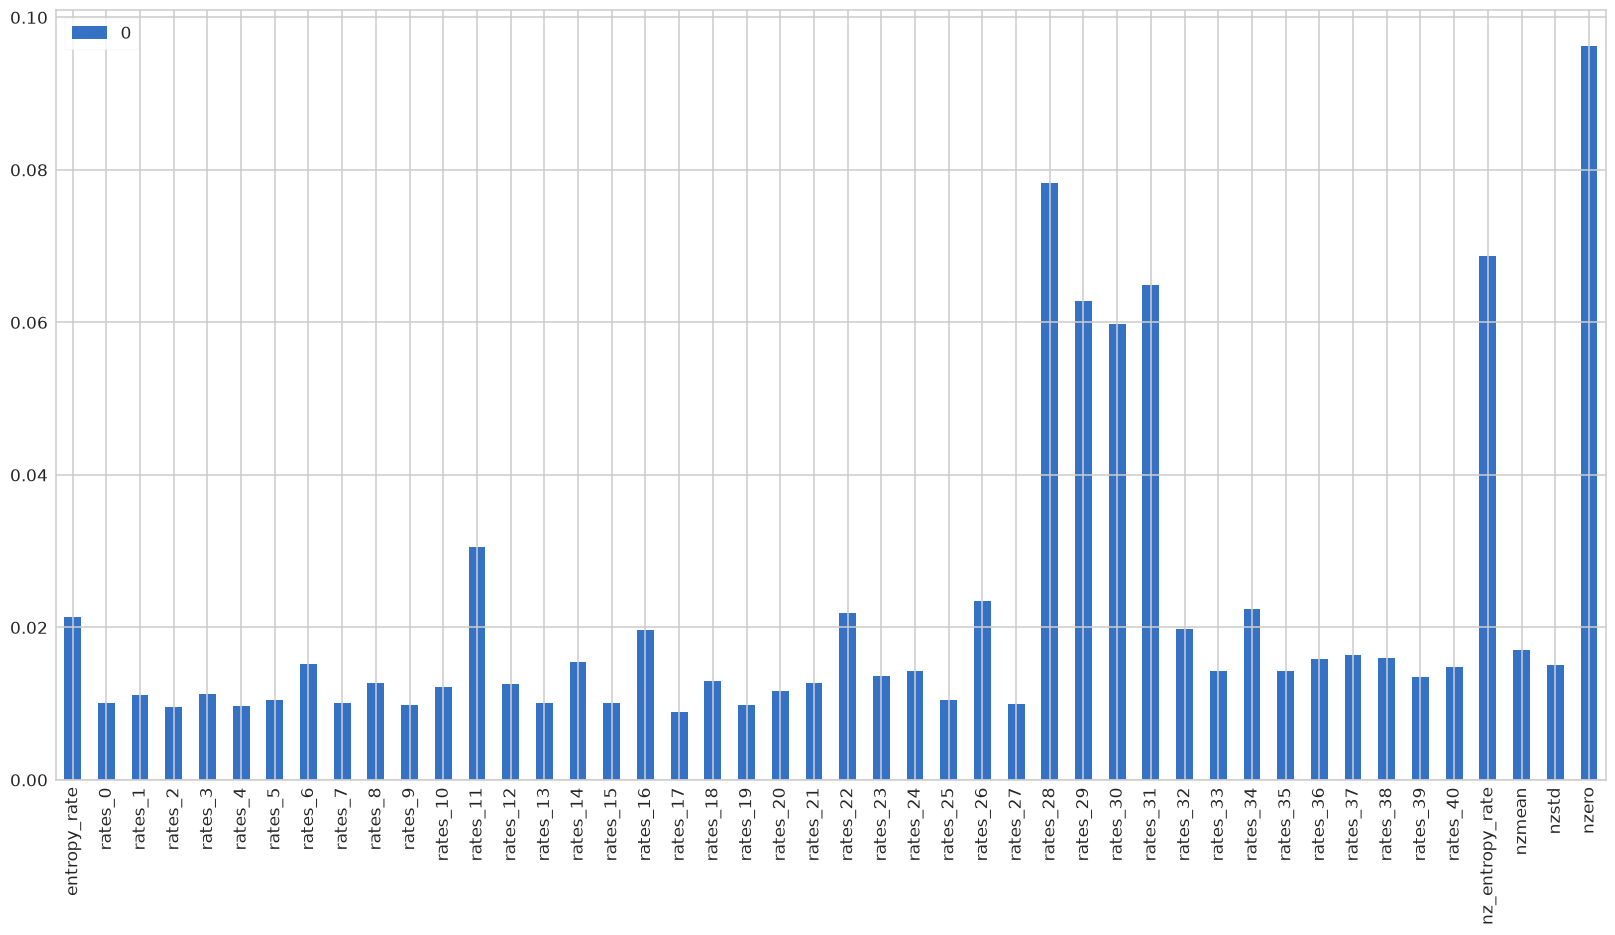

In [28]:
plt.figure(figsize=[20,10])
pd.DataFrame(models[0].feature_importances_,[x for x in df_.columns if x not in ['perplexity','percentage', 'label']]).plot(ax=plt.gca(),kind='bar')


In [29]:
modeldf_=[pd.DataFrame(ROC[model_]) for model_ in modelnames]
ztc=zedstat.processRoc(df=modeldf_[-1],
           order=3, 
           total_samples=len(y_test),
           positive_samples=y_test.sum(),
           alpha=0.01,
           prevalence=.5)

ztc.smooth(STEP=0.001)
ztc.allmeasures(interpolate=True)
ztc.usample(precision=2)
ztc.getBounds()

auc_c=np.array(ztc.auc(alpha=.05))*100
deltac=(auc_c[1]-auc_c[2])/2
lc=str(auc_c[0])[:4]+'%'
ztc.auc(alpha=.05)

(0.9861249189680752,
 np.float64(0.9908071053998215),
 np.float64(0.9814427325363289))

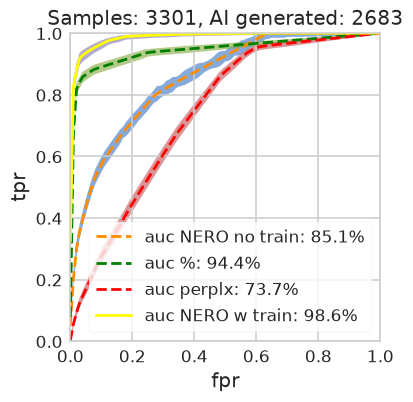

In [30]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
ax=ztpc.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
ax=ztpx.get().tpr.plot(style='--',ax=ax,color='red',lw=2)
ax=ztc.get().tpr.plot(style='-',ax=ax,color='yellow',lw=2)

plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpc.get().index, y1=ztpc.df_lim['U'].tpr,y2=ztpc.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpx.get().index, y1=ztpx.df_lim['U'].tpr,y2=ztpx.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztc.get().index, y1=ztc.df_lim['U'].tpr,y2=ztc.df_lim['L'].tpr, alpha=.6)


dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_notraining.csv')
dx=pd.DataFrame({'tpr_upper':ztpc.df_lim['U'].tpr,'tpr_lower':ztpc.df_lim['L'].tpr}).join(ztpc.get()['tpr'])
dx.to_csv('percentage_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztpx.df_lim['U'].tpr,'tpr_lower':ztpx.df_lim['L'].tpr}).join(ztpx.get()['tpr'])
dx.to_csv('perplexity_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztc.df_lim['U'].tpr,'tpr_lower':ztc.df_lim['L'].tpr}).join(ztc.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_trained.csv')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO no train: '+le,'auc %: '+lpc,'auc perplx: '+lpx, 'auc NERO w train: '+lc],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining'+SUBSET+'.pdf',bbox_inches='tight',transparent=True)